# Phase 2: Text Preprocessing

Project : MBTI Personality Type Prediction from Text
Dataset : https://www.kaggle.com/datasets/datasnaek/mbti-type

Internet forum text is extremely noisy.  Before any model can learn
meaningful patterns, we must:
1. Remove structural artefacts  (post separators, URLs, emails)
2. Normalise casing and characters
3. Remove data-leaking tokens   (MBTI acronyms like "INFP" appear in
posts because users discuss their own types)
4. Strip stopwords             (common words that carry no personality
signal: "the", "is", "and", etc.)
5. Lemmatize                   (reduce words to their base form so
"running" / "ran" / "runs" all become "run")

The result is a new column 'clean_posts' that is model-ready.


In [1]:
%matplotlib inline

In [2]:
# -- Imports ------------------------------------------------------------------
import os
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# -- Configuration ------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

DATA_PATH = os.path.join(os.getcwd(), "mbti_1.csv")
OUTPUT_PATH = os.path.join(os.getcwd(), "mbti_cleaned.csv")

## CONSTANTS


In [3]:
# All 16 MBTI personality type acronyms (both upper and lower case).
# These MUST be removed from the text to prevent data leakage.
# Why? Users on PersonalityCafe frequently write things like:
#   "As an INFP, I feel..."  or  "That's such an ENTJ thing to do."
# If left in, the model would just learn to look for these tokens
# instead of actual linguistic patterns.
MBTI_TYPES = [
    "infp", "infj", "intp", "intj",
    "isfp", "isfj", "istp", "istj",
    "enfp", "enfj", "entp", "entj",
    "esfp", "esfj", "estp", "estj",
]

# Jungian cognitive function abbreviations.
# Forum users frequently discuss functions like "my dominant Ni" or
# "strong Fe users".  These are direct proxies for MBTI type.
COGNITIVE_FUNCTIONS = [
    "ni", "ne", "si", "se",   # iNtuition / Sensing (introverted/extraverted)
    "ti", "te", "fi", "fe",   # Thinking / Feeling   (introverted/extraverted)
]

# Temperament group codes.  "NT" = iNtuitive-Thinking, etc.
# Users say "as an NF type..." which leaks their axis directly.
TEMPERAMENT_GROUPS = [
    "nt", "nf", "sf", "st",   # 2-letter temperament groups
    "sj", "sp", "nj", "np",   # Keirsey interaction style groups
]

# Wildcard MBTI references: users write "xNFP" meaning "any NFP type".
# The "x" stands for "either E or I".  These leak axis information.
MBTI_WILDCARDS = [
    "xnfp", "xnfj", "xntp", "xntj",
    "xsfp", "xsfj", "xstp", "xstj",
    "xnfx", "xntx", "xsfx", "xstx",   # double-wildcard forms
]

# Meta terms -- references to the personality system itself.
# Also includes Enneagram instinctual variant codes (sx/so/sp) that
# appear frequently on PersonalityCafe alongside MBTI discussion.
MBTI_META = ["mbti", "myers", "briggs", "jungian", "enneagram", "socionics",
             "sx", "so"]  # sx = sexual instinct, so = social instinct

# ---- Build a SINGLE compiled regex that catches ALL of the above -----------
# For the 16 MBTI types, also match optional trailing "s" (plural: "infps")
# and optional "'s" or "s" possessive forms.
_mbti_with_suffix = [t + r"(?:s|'s)?" for t in MBTI_TYPES]

# Cognitive functions and temperament groups: exact match only (short words).
_all_leak_tokens = (
    _mbti_with_suffix
    + COGNITIVE_FUNCTIONS
    + TEMPERAMENT_GROUPS
    + MBTI_WILDCARDS
    + MBTI_META
)

# Compile with word boundaries so we don't corrupt normal words.
MBTI_PATTERN = re.compile(
    r"\b(" + "|".join(_all_leak_tokens) + r")\b",
    flags=re.IGNORECASE,
)

# Precompile other regex patterns for performance (applied 8,675 times).
URL_PATTERN      = re.compile(r"https?://\S+|www\.\S+")
EMAIL_PATTERN    = re.compile(r"\S+@\S+\.\S+")
# Keep only letters and whitespace (remove digits, punctuation, etc.)
NON_ALPHA_PATTERN = re.compile(r"[^a-z\s]")
# Collapse multiple whitespace into a single space
MULTI_SPACE       = re.compile(r"\s+")

# Load English stopwords once, extended with URL residue fragments.
# After non-alpha stripping, URLs like "http://youtube.com" become
# "http youtube com" — these leftover tokens carry no personality signal.
URL_RESIDUE = {"http", "https", "www", "com", "org", "net", "edu", "gov",
               "html", "htm", "php", "asp", "aspx", "jpg", "jpeg", "png",
               "gif", "youtube", "imgur", "tumblr", "wordpress", "blogspot"}
STOP_WORDS = set(stopwords.words("english")) | URL_RESIDUE

# Also store ALL leak tokens as a set for fast O(1) token-level filtering.
# This is the FINAL safety net applied after lemmatization.
MBTI_SET = (
    set(MBTI_TYPES)
    | {t + "s" for t in MBTI_TYPES}          # plurals
    | set(COGNITIVE_FUNCTIONS)
    | set(TEMPERAMENT_GROUPS)
    | set(MBTI_WILDCARDS)
    | set(MBTI_META)
)

# Initialise the lemmatizer once
LEMMATIZER = WordNetLemmatizer()

## CORE PREPROCESSING FUNCTION


In [4]:
def preprocess_text(text: str) -> str:
    """
    Clean a single user's concatenated posts string.

    Pipeline (order matters!):
    --------------------------
    1. Replace post separators '|||' with a space
    2. Convert to lowercase  (before regex matching)
    3. Remove URLs           (http/https links, www.*)
    4. Remove email addresses
    5. Remove MBTI acronyms  (FIRST PASS — on raw-ish text)
    6. Remove non-alphabetic characters  (digits, punctuation)
    7. Remove MBTI acronyms  (SECOND PASS — catches acronyms that were
       embedded in punctuated strings and only became word-bounded
       after the non-alpha pass, e.g., "gohanu infp piccolou")
    8. Tokenize into individual words
    9. Remove stopwords + MBTI types at token level (FINAL safety net)
    10. Lemmatize each remaining token
    11. Rejoin into a clean string

    Parameters
    ----------
    text : str
        The raw 'posts' column value for one user (50 posts joined by '|||').

    Returns
    -------
    str
        Cleaned, lemmatized, stopword-free text.
    """
    # Step 1: Replace the '|||' post separator with a space.
    # This merges all 50 posts into a single continuous block of text.
    text = text.replace("|||", " ")

    # Step 2: Lowercase everything.
    # This normalises "Hello" and "hello" to the same token.
    text = text.lower()

    # Step 3: Strip URLs.
    # Forum posts are full of YouTube links, image links, etc.
    text = URL_PATTERN.sub("", text)

    # Step 4: Strip email addresses.
    text = EMAIL_PATTERN.sub("", text)

    # Step 5: Remove MBTI type acronyms (FIRST PASS).
    # CRITICAL for preventing data leakage. Without this, the model would
    # cheat by detecting "I'm an INFP" in the text.
    text = MBTI_PATTERN.sub("", text)

    # Step 6: Remove all non-alphabetic characters.
    # This strips digits, punctuation, emojis, etc.  We only keep [a-z]
    # and whitespace.
    text = NON_ALPHA_PATTERN.sub(" ", text)

    # Step 7: Remove MBTI acronyms AGAIN (SECOND PASS).
    # After stripping non-alpha chars, some acronyms that were glued to
    # punctuation now appear as standalone words.
    text = MBTI_PATTERN.sub("", text)

    # Step 8: Collapse any runs of whitespace into a single space.
    text = MULTI_SPACE.sub(" ", text).strip()

    # Step 9: Tokenize into individual words.
    tokens = text.split()  # Fast whitespace split (sufficient post-regex)

    # Step 10: Remove stopwords, MBTI types (token-level safety net),
    # URL residue words, and very short tokens (length <= 1).
    tokens = [t for t in tokens
              if t not in STOP_WORDS
              and t not in MBTI_SET
              and len(t) > 1]

    # Step 11: Lemmatize each token to its base/dictionary form.
    # "running" -> "run",  "better" -> "better" (adjective lemmatization
    # requires POS tagging, which we skip for speed; verb lemma is enough).
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    # Step 12: FINAL safety net -- remove any MBTI-related tokens that
    # survived lemmatization (e.g., a plural that lemmatized back to
    # an MBTI term).  This guarantees zero leakage.
    tokens = [t for t in tokens if t not in MBTI_SET]

    # Rejoin into a single clean string.
    return " ".join(tokens)

## APPLY PREPROCESSING TO DATAFRAME


In [5]:
def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply the preprocessing pipeline to the entire 'posts' column.

    Creates a new column 'clean_posts'.  Also tracks execution time
    and prints a before/after comparison for sanity checking.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain a 'posts' column.

    Returns
    -------
    pd.DataFrame
        The same dataframe with an added 'clean_posts' column.
    """
    df = df.copy()

    print("=" * 60)
    print("  PHASE 2: TEXT PREPROCESSING")
    print("=" * 60)
    print(f"  Processing {len(df)} rows ...")

    # Time the operation
    start = time.time()
    df["clean_posts"] = df["posts"].apply(preprocess_text)
    elapsed = time.time() - start

    print(f"  Done in {elapsed:.1f}s  ({elapsed / len(df) * 1000:.1f} ms/row)")
    print("=" * 60)

    return df

## VERIFICATION & QUALITY CHECKS


In [6]:
def verify_preprocessing(df: pd.DataFrame) -> None:
    """
    Run a suite of sanity checks on the cleaned text.

    Things we verify:
        - No MBTI acronyms survive in clean_posts
        - No URLs survive
        - No empty rows after cleaning
        - Before/after comparison of sample rows
    """
    print("\n" + "-" * 60)
    print("  PREPROCESSING VERIFICATION")
    print("-" * 60)

    # -- Check 1: No MBTI acronyms remaining ---------------------------------
    mbti_leaks = 0
    for mbti in MBTI_TYPES:
        # Search for the MBTI acronym as a standalone word
        pattern = r"\b" + mbti + r"\b"
        matches = df["clean_posts"].str.contains(pattern, case=False, na=False)
        count = matches.sum()
        if count > 0:
            mbti_leaks += count
            print(f"  WARNING: '{mbti.upper()}' found in {count} rows!")

    if mbti_leaks == 0:
        print("  [PASS] No MBTI acronyms detected in clean_posts")
    else:
        print(f"  [FAIL] {mbti_leaks} MBTI leaks detected!")

    # -- Check 2: No URLs remaining ------------------------------------------
    url_matches = df["clean_posts"].str.contains(r"http|www\.", na=False).sum()
    if url_matches == 0:
        print("  [PASS] No URLs detected in clean_posts")
    else:
        print(f"  [FAIL] {url_matches} rows still contain URLs!")

    # -- Check 3: No empty rows ----------------------------------------------
    empty_rows = (df["clean_posts"].str.strip() == "").sum()
    null_rows = df["clean_posts"].isnull().sum()
    if empty_rows == 0 and null_rows == 0:
        print(f"  [PASS] No empty or null rows (all {len(df)} rows have content)")
    else:
        print(f"  [WARN] {empty_rows} empty rows, {null_rows} null rows")

    # -- Check 4: Word count comparison (before vs after) ---------------------
    df_temp = df.copy()
    df_temp["raw_wc"]   = df_temp["posts"].apply(lambda x: len(x.split()))
    df_temp["clean_wc"] = df_temp["clean_posts"].apply(lambda x: len(x.split()))
    reduction = (1 - df_temp["clean_wc"].sum() / df_temp["raw_wc"].sum()) * 100

    print(f"\n  Word count reduction:")
    print(f"    Raw total   : {df_temp['raw_wc'].sum():,} words")
    print(f"    Clean total : {df_temp['clean_wc'].sum():,} words")
    print(f"    Reduction   : {reduction:.1f}%")

    # -- Check 5: Before / After samples -------------------------------------
    print(f"\n  BEFORE vs AFTER (first 2 rows):")
    print("  " + "-" * 56)
    for i in range(min(2, len(df))):
        raw_preview = df.iloc[i]["posts"][:150]
        clean_preview = df.iloc[i]["clean_posts"][:150]
        print(f"\n  Row {i} [{df.iloc[i]['type']}]:")
        print(f"    RAW   : {raw_preview} ...")
        print(f"    CLEAN : {clean_preview} ...")

    print("\n" + "-" * 60)

## VISUALISE PREPROCESSING EFFECTS


In [7]:
def plot_preprocessing_effects(df: pd.DataFrame) -> None:
    """
    Visual comparison of word counts before and after preprocessing.
    Shows the cleaning impact and confirms the pipeline is working.
    """
    df = df.copy()
    df["raw_wc"]   = df["posts"].apply(lambda x: len(x.split()))
    df["clean_wc"] = df["clean_posts"].apply(lambda x: len(x.split()))

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # -- Plot 1: Side-by-side histograms -------------------------------------
    ax1 = axes[0]
    ax1.hist(df["raw_wc"], bins=50, alpha=0.6, color="#E74C3C", label="Raw", edgecolor="white")
    ax1.hist(df["clean_wc"], bins=50, alpha=0.6, color="#2ECC71", label="Cleaned", edgecolor="white")
    ax1.axvline(df["raw_wc"].mean(), color="#C0392B", linestyle="--", linewidth=1.5)
    ax1.axvline(df["clean_wc"].mean(), color="#27AE60", linestyle="--", linewidth=1.5)
    ax1.set_title("Word Count: Raw vs Cleaned", fontweight="bold")
    ax1.set_xlabel("Word Count")
    ax1.set_ylabel("Number of Users")
    ax1.legend(fontsize=11)

    # -- Plot 2: Scatter — raw vs cleaned word count -------------------------
    ax2 = axes[1]
    ax2.scatter(df["raw_wc"], df["clean_wc"], alpha=0.3, s=10, color="#3498DB")
    ax2.plot([0, df["raw_wc"].max()], [0, df["raw_wc"].max()],
             "r--", alpha=0.5, label="y = x (no reduction)")
    ax2.set_title("Raw vs Cleaned Word Count (per user)", fontweight="bold")
    ax2.set_xlabel("Raw Word Count")
    ax2.set_ylabel("Cleaned Word Count")
    ax2.legend(fontsize=10)

    # -- Plot 3: Reduction % by MBTI type ------------------------------------
    ax3 = axes[2]
    df["reduction_pct"] = (1 - df["clean_wc"] / df["raw_wc"]) * 100
    type_order = df.groupby("type")["reduction_pct"].mean().sort_values(ascending=False).index

    sns.barplot(
        data=df, x="type", y="reduction_pct",
        order=type_order, ax=ax3,
        palette="coolwarm", errorbar=None,
    )
    ax3.set_title("Avg Word Reduction % by MBTI Type", fontweight="bold")
    ax3.set_xlabel("MBTI Type")
    ax3.set_ylabel("Reduction (%)")
    ax3.tick_params(axis="x", rotation=45)
    ax3.axhline(df["reduction_pct"].mean(), color="black", linestyle="--",
                linewidth=1, label=f"Overall mean: {df['reduction_pct'].mean():.1f}%")
    ax3.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig("eda_preprocessing_effects.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart saved: eda_preprocessing_effects.png")

## SAVE CLEANED DATA


In [8]:
def save_cleaned_data(df: pd.DataFrame, path: str = OUTPUT_PATH) -> None:
    """
    Save the preprocessed dataframe to CSV for use in Phase 3.
    """
    df.to_csv(path, index=False)
    size_mb = os.path.getsize(path) / 1e6
    print(f"\n  Cleaned data saved to: {path}")
    print(f"  File size: {size_mb:.2f} MB")
    print(f"  Columns: {list(df.columns)}")

## MAIN


In [9]:
def main():
    """Execute the full Phase 2 preprocessing pipeline."""

    # Step 1: Load raw data
    print("Loading raw dataset ...")
    df = pd.read_csv(DATA_PATH)
    print(f"  Loaded {len(df)} rows.\n")

    # Step 2: Apply preprocessing
    df = preprocess_dataframe(df)

    # Step 3: Verify the cleaning worked
    verify_preprocessing(df)

    # Step 4: Visualise the effects
    plot_preprocessing_effects(df)

    # Step 5: Save to CSV
    save_cleaned_data(df)

    print("\n[DONE]  Phase 2 preprocessing complete.")
    print("    Next -> Phase 3: Feature Engineering & Model Training\n")

    return df

## Run Phase 2


Loading raw dataset ...


  Loaded 8675 rows.

  PHASE 2: TEXT PREPROCESSING
  Processing 8675 rows ...


  Done in 50.7s  (5.8 ms/row)

------------------------------------------------------------
  PREPROCESSING VERIFICATION
------------------------------------------------------------


  [PASS] No MBTI acronyms detected in clean_posts
  [PASS] No URLs detected in clean_posts
  [WARN] 1 empty rows, 0 null rows



  Word count reduction:
    Raw total   : 10,637,645 words
    Clean total : 5,034,840 words
    Reduction   : 52.7%

  BEFORE vs AFTER (first 2 rows):
  --------------------------------------------------------

  Row 0 [INFJ]:
    RAW   : 'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtu ...
    CLEAN : moment sportscenter top ten play prank life changing experience life repeat today may perc experience immerse last thing friend posted facebook commit ...

  Row 1 [ENTP]:
    RAW   : 'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the same position often. For example me and my girlfriend are ...
    CLEAN : finding lack post alarming sex boring position often example girlfriend currently environment creatively use cowgirl missionary enough giving new mean ...

------------------------------------------------------------


C:\Users\rudra\AppData\Local\Temp\ipykernel_16924\2866022309.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


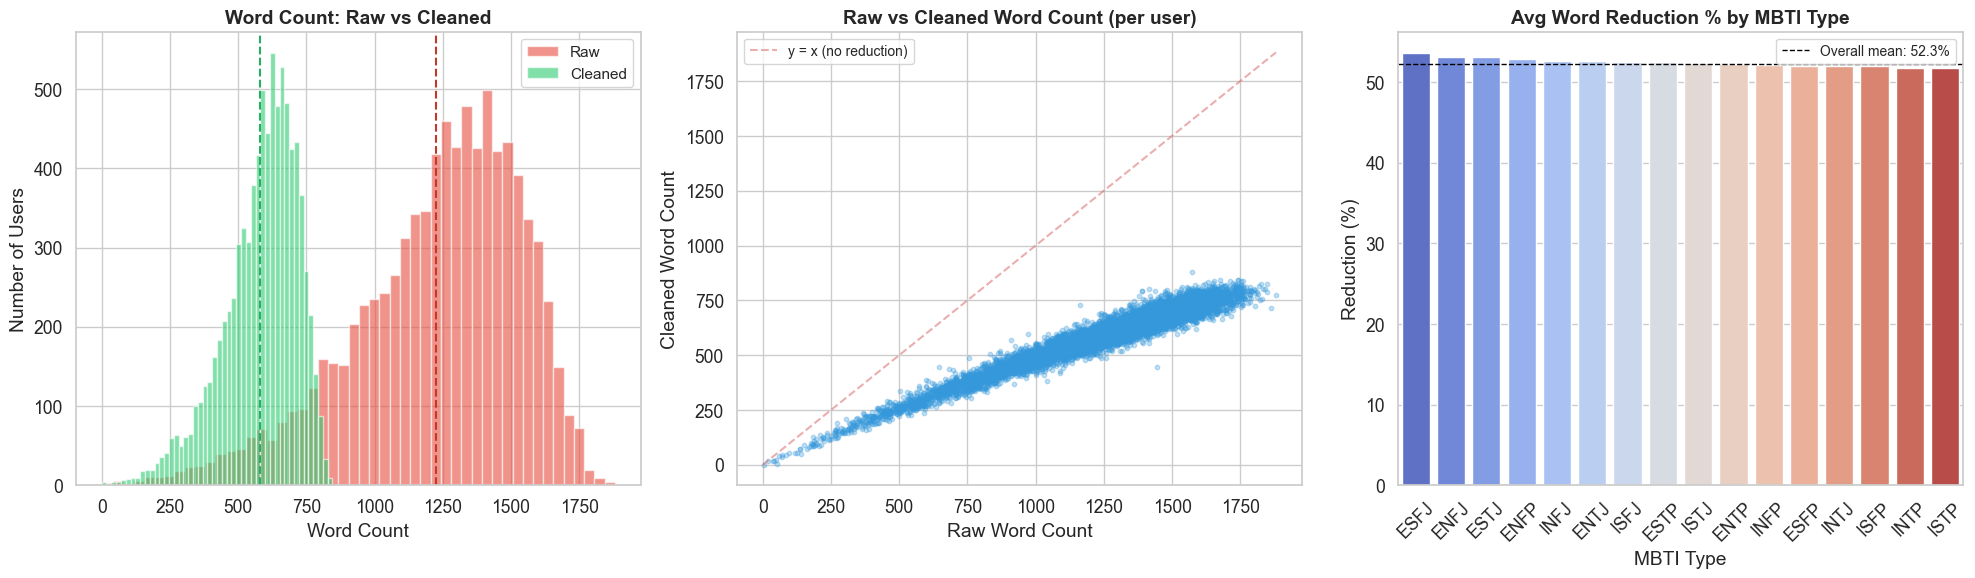

  Chart saved: eda_preprocessing_effects.png



  Cleaned data saved to: C:\Users\rudra\OneDrive\Desktop\Prml Project\mbti_cleaned.csv
  File size: 96.77 MB
  Columns: ['type', 'posts', 'clean_posts']

[DONE]  Phase 2 preprocessing complete.
    Next -> Phase 3: Feature Engineering & Model Training



In [10]:
df = main()